In [1]:
%matplotlib ipympl

In [2]:
from pathlib import Path

import numpy as np
import pandas as pd
import scipy.io
import scipy.signal
from matplotlib import pyplot as plt
from tqdm import tqdm

In [3]:
csvs_dir = Path('../csvs')

In [ ]:
ppg_dir = Path('../data/ppg')

In [5]:
images_dir = Path('../images')

In [6]:
df_subjects = pd.read_csv(csvs_dir / 'subjects.csv')

In [7]:
df_subjects['patient_file'] = df_subjects.apply(lambda r: ppg_dir / f'p{r["subject_id"]:06d}_{r["segment_id"]}.mat', axis=1)

In [8]:
df_samples = df_subjects.groupby('class').sample(5, random_state=0)[['subject_id', 'class', 'patient_file']].sort_values(['class', 'subject_id'])

In [9]:
fs = 125

In [10]:
experiment_sets = {

    # title
    #   filter      order   freqs   att     label

    # 'frequency search: lowpass, butterworth, 4th order': [
    #     (None,      None,   None,   None,   'raw'),
    #     ('butter',  4,      10,     None,   'butter, 10 hz'),
    #     ('butter',  4,      30,     None,   'butter, 30 hz'),
    # ],

    # 'attenuation search: chebyshev type 2, 4th order, lowpass, 10 hz': [
    #     (None,      None,   None,   None,   'raw'),
    #     ('cheby2',  4,      10,     20,     'cheby2, 10 hz, 20 db'),
    #     ('cheby2',  4,      10,     40,     'cheby2, 10 hz, 40 db'),
    #     ('cheby2',  4,      10,     60,     'cheby2, 10 hz, 60 db'),
    #     ('cheby2',  4,      10,     80,     'cheby2, 10 hz, 80 db'),
    # ],

    # 'attenuation search: chebyshev type 2, 4th order, lowpass, 30 hz': [
    #     (None,      None,   None,   None,   'raw'),
    #     ('cheby2',  4,      30,     20,     'cheby2, 30 hz, 20 db'),
    #     ('cheby2',  4,      30,     40,     'cheby2, 30 hz, 40 db'),
    #     ('cheby2',  4,      30,     60,     'cheby2, 30 hz, 60 db'),
    #     ('cheby2',  4,      30,     80,     'cheby2, 30 hz, 80 db'),
    # ],

    'frequency search: chebyshev type 2, 4th order, lowpass, 40 db': [
        (None,      None,   None,   None,   'raw'),
        ('cheby2',  4,      10,     40,     'cheby2, 10 hz, 40 db'),
        ('cheby2',  4,      15,     40,     'cheby2, 15 hz, 40 db'),
        ('cheby2',  4,      30,     40,     'cheby2, 30 hz, 40 db'),
        ('cheby2',  4,      35,     40,     'cheby2, 35 hz, 40 db'),
        ('cheby2',  4,      40,     40,     'cheby2, 35 hz, 40 db'),
    ],

    # 'frequency search: chebyshev type 2, 4th order, bandpass, 40 db': [
    #     ('detrend', None,   None,           None,   'detrend'),
    #     ('cheby2',  4,      [0.03, 30],     40,     'cheby2, 0.03 - 30 hz, 40 db'),
    #     ('cheby2',  4,      [0.1, 30],      40,     'cheby2, 0.1 - 30 hz, 40 db'),
    #     ('cheby2',  4,      [0.5, 30],      40,     'cheby2, 0.5 - 30 hz, 40 db'),
    # ],

}

In [11]:
alpha = 1.0

In [12]:
# plt.rcParams.update({'font.size': 16})

In [13]:
iterator = list(df_samples.itertuples(index=False))[-1:]

In [14]:
subject_id, category, patient_file = iterator[0]

In [15]:
mat = scipy.io.loadmat(patient_file)

In [16]:
t = mat['time'].squeeze()
ppg = mat['data'].squeeze()

In [17]:
name, experiments = list(experiment_sets.items())[0]

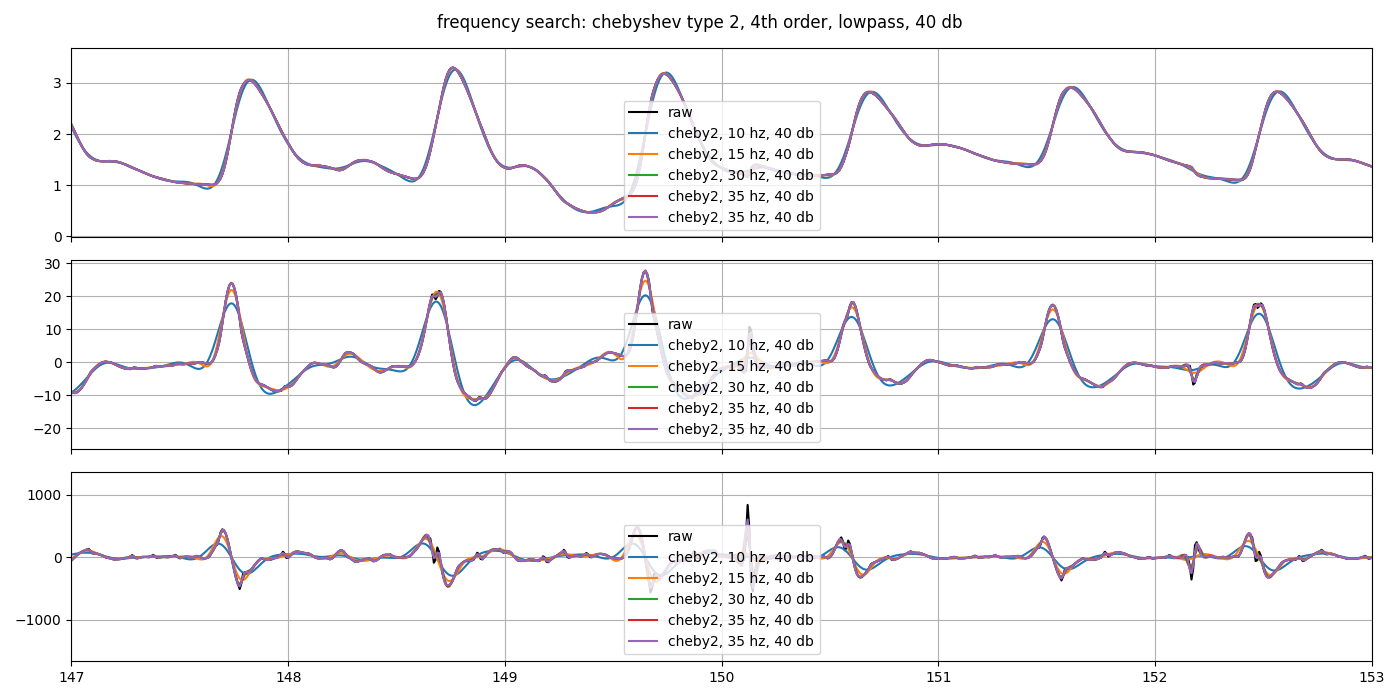

In [21]:
fig, axes = plt.subplots(3, 1, sharex=True, figsize=(14, 7))
axes: tuple[plt.Axes]

for filter_type, n, wn, rs, label in experiments:
    kwargs = {'alpha': alpha, 'label': label}
    if filter_type is None:
        kwargs['color'] = 'black'
        ppgf = ppg
    elif filter_type == 'detrend':
        kwargs['color'] = 'black'
        ppgf = scipy.signal.detrend(ppg, type='constant')
    elif filter_type == 'butter':
        b, a = scipy.signal.butter(n, wn, btype='band' if isinstance(wn, list) else 'low', fs=fs)
        ppgf = scipy.signal.filtfilt(b, a, ppg)
    elif filter_type == 'cheby2':
        b, a = scipy.signal.cheby2(n, rs, wn, btype='band' if isinstance(wn, list) else 'low', fs=fs)
        ppgf = scipy.signal.filtfilt(b, a, ppg)
    else:
        raise NotImplementedError

    axes[0].plot(t, ppgf, **kwargs)
    axes[1].plot(t, np.gradient(ppgf, t), **kwargs)
    axes[2].plot(t, np.gradient(np.gradient(ppgf, t), t), **kwargs)

axes[0].legend()
axes[0].grid(True)
axes[1].legend()
axes[1].grid(True)
axes[2].legend()
axes[2].grid(True)

fig.suptitle(name)

plt.xlim(147, 153)
fig.tight_layout()